In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Notebook siap!")
print(f"pandas versi: {pd.__version__}")
print(f"Numpy versi: {np.__version__}")

Notebook siap!
pandas versi: 3.0.6
Numpy versi: 2.5.3


In [4]:
# Load dataset Excel
df = pd.read_excel("../data/raw/Data Cuaca Harian SulawesiTenggara.xlsx")

# Lihat 5 baris pertama
df.head()

,Tanggal,Temperatur minimum (°C),Temperatur maximum(°C),temperatur rata-rata(°C),kelembapan rata-rata(%),curah hujan(mm),lamanya penyinaran matahari(jam),kecepatan angin rata-rata(m/s)
0,01-01-2022,24.0,32.2,27.0,84.0,1.0,3.5,1.0
1,02-01-2022,24.0,31.2,25.8,91.0,8.1,2.5,1.0
2,03-01-2022,22.4,32.0,26.3,86.0,29.3,2.0,1.0
3,04-01-2022,24.0,29.8,26.7,87.0,0.5,5.5,0.0
4,05-01-2022,23.4,32.2,26.9,85.0,22.3,0.0,0.0


In [5]:
# Berapa baris dan kolom?
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Nama kolom    : {df.columns.tolist()}")

Jumlah baris  : 699
Jumlah kolom  : 8
Nama kolom    : ['Tanggal', 'Temperatur minimum (°C)', 'Temperatur maximum(°C)', 'temperatur rata-rata(°C)', 'kelembapan rata-rata(%)', 'curah hujan(mm)', 'lamanya penyinaran matahari(jam)', 'kecepatan angin rata-rata(m/s)']


In [6]:
# Lihat tipe data tiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Tanggal                           699 non-null    str    
 1   Temperatur minimum (°C)           693 non-null    float64
 2   Temperatur maximum(°C)            690 non-null    float64
 3   temperatur rata-rata(°C)          688 non-null    float64
 4   kelembapan rata-rata(%)           688 non-null    float64
 5   curah hujan(mm)                   691 non-null    float64
 6   lamanya penyinaran matahari(jam)  694 non-null    float64
 7   kecepatan angin rata-rata(m/s)    695 non-null    float64
dtypes: float64(7), str(1)
memory usage: 43.8 KB


In [7]:
# Convert kolom Tanggal dari teks ke tanggal
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d-%m-%Y')

# Cek berhasil
print(f"Tipe data Tanggal sekarang: {df['Tanggal'].dtype}")
print(f"Tanggal paling awal : {df['Tanggal'].min()}")
print(f"Tanggal paling akhir: {df['Tanggal'].max()}")

Tipe data Tanggal sekarang: datetime64[us]
Tanggal paling awal : 2022-01-01 00:00:00
Tanggal paling akhir: 2023-11-30 00:00:00


In [8]:
# Persentase data kosong per kolom
missing_persen = (df.isnull().sum() / len(df)) * 100
missing_persen = missing_persen.sort_values(ascending=False)
print(missing_persen[missing_persen > 0])

temperatur rata-rata(°C)            1.573677
kelembapan rata-rata(%)             1.573677
Temperatur maximum(°C)              1.287554
curah hujan(mm)                     1.144492
Temperatur minimum (°C)             0.858369
lamanya penyinaran matahari(jam)    0.715308
kecepatan angin rata-rata(m/s)      0.572246
dtype: float64


In [9]:
# Isi data kosong dengan rata-rata kolom
kolom_angka = df.select_dtypes(include='number').columns
df[kolom_angka] = df[kolom_angka].fillna(df[kolom_angka].mean())

# Cek hasil - harusnya semua 0
print("Data kosong setelah dibersihkan:")
print(df.isnull().sum())

Data kosong setelah dibersihkan:
Tanggal                             0
Temperatur minimum (°C)             0
Temperatur maximum(°C)              0
temperatur rata-rata(°C)            0
kelembapan rata-rata(%)             0
curah hujan(mm)                     0
lamanya penyinaran matahari(jam)    0
kecepatan angin rata-rata(m/s)      0
dtype: int64


In [10]:
# Statistik ringkas setelah dibersihkan
df.describe().round(2)

,Tanggal,Temperatur minimum (°C),Temperatur maximum(°C),temperatur rata-rata(°C),kelembapan rata-rata(%),curah hujan(mm),lamanya penyinaran matahari(jam),kecepatan angin rata-rata(m/s)
count,699,699.00,699.00,699.00,699.00,699.00,699.00,699.00
mean,2022-12-16 00:00:00,37.88,46.64,27.13,83.99,1034.49,33.32,0.95
min,2022-01-01 00:00:00,18.20,23.90,23.70,57.00,0.00,0.00,0.00
25%,2022-06-24 12:00:00,23.10,31.20,26.30,81.00,0.00,2.40,1.00
50%,2022-12-16 00:00:00,23.80,32.30,27.00,85.00,1.50,4.50,1.00
75%,2023-06-08 12:00:00,24.40,33.30,27.80,88.00,13.65,6.80,1.00
max,2023-11-30 00:00:00,9999.00,9999.00,32.80,99.00,8888.00,9999.00,5.00
std,NaN,377.31,376.98,1.38,6.47,2827.51,534.23,0.70


In [11]:
# Lihat nama kolom persis (perhatikan karakter anehnya)
for i, col in enumerate(df.columns):
    print(f"{i}: '{col}'")

0: 'Tanggal'
1: 'Temperatur minimum (°C)'
2: 'Temperatur maximum(°C)'
3: 'temperatur rata-rata(°C)'
4: 'kelembapan rata-rata(%)'
5: 'curah hujan(mm)'
6: 'lamanya penyinaran matahari(jam)'
7: 'kecepatan angin rata-rata(m/s)'


In [12]:
# Rename kolom berdasarkan urutan (index) - paling aman
df.columns = [
    'tanggal',
    'suhu_min',
    'suhu_max',
    'suhu_rata',
    'kelembapan',
    'curah_hujan',
    'penyinaran',
    'kecepatan_angin'
]

# Cek hasil
print("Kolom baru:")
print(df.columns.tolist())
print()
df.head(3)

Kolom baru:
['tanggal', 'suhu_min', 'suhu_max', 'suhu_rata', 'kelembapan', 'curah_hujan', 'penyinaran', 'kecepatan_angin']



,tanggal,suhu_min,suhu_max,suhu_rata,kelembapan,curah_hujan,penyinaran,kecepatan_angin
0,2022-01-01,24.0,32.2,27.0,84.0,1.0,3.5,1.0
1,2022-01-02,24.0,31.2,25.8,91.0,8.1,2.5,1.0
2,2022-01-03,22.4,32.0,26.3,86.0,29.3,2.0,1.0


In [13]:
# Cari hari paling panas & paling dingin
suhu_max_idx = df['suhu_rata'].idxmax()
suhu_min_idx = df['suhu_rata'].idxmin()

print("=== SUHU EKSTREM ===")
print(f"Hari paling panas : {df.loc[suhu_max_idx, 'tanggal'].date()}")
print(f"  Suhu rata-rata  : {df.loc[suhu_max_idx, 'suhu_rata']}°C")
print(f"  Suhu maksimum   : {df.loc[suhu_max_idx, 'suhu_max']}°C")
print()
print(f"Hari paling dingin: {df.loc[suhu_min_idx, 'tanggal'].date()}")
print(f"  Suhu rata-rata  : {df.loc[suhu_min_idx, 'suhu_rata']}°C")
print(f"  Suhu minimum    : {df.loc[suhu_min_idx, 'suhu_min']}°C")

=== SUHU EKSTREM ===
Hari paling panas : 2023-11-15
  Suhu rata-rata  : 32.8°C
  Suhu maksimum   : 36.6°C

Hari paling dingin: 2022-06-22
  Suhu rata-rata  : 23.7°C
  Suhu minimum    : 23.0°C


In [14]:
# Cari hari paling hujan
hujan_idx = df['curah_hujan'].idxmax()

print("=== CURAH HUJAN ===")
print(f"Hari paling hujan : {df.loc[hujan_idx, 'tanggal'].date()}")
print(f"Curah hujan       : {df.loc[hujan_idx, 'curah_hujan']} mm")
print()
print(f"Hari hujan (curah > 0) : {(df['curah_hujan'] > 0).sum()} hari")
print(f"Hari kering (curah = 0): {(df['curah_hujan'] == 0).sum()} hari")
print(f"Rata-rata curah hujan  : {df['curah_hujan'].mean():.2f} mm/hari")

=== CURAH HUJAN ===
Hari paling hujan : 2022-01-17
Curah hujan       : 8888.0 mm

Hari hujan (curah > 0) : 438 hari
Hari kering (curah = 0): 261 hari
Rata-rata curah hujan  : 1034.49 mm/hari


In [15]:
# Tambah kolom bulan
df['bulan'] = df['tanggal'].dt.to_period('M')

# Ringkasan per bulan
ringkasan = df.groupby('bulan').agg({
    'suhu_rata': 'mean',
    'curah_hujan': 'sum',
    'kelembapan': 'mean'
}).round(2)

ringkasan

,suhu_rata,curah_hujan,kelembapan
bulan,,,
2022-01,27.14,9028.90,83.32
2022-02,26.94,17955.10,84.82
2022-03,26.95,44760.70,86.48
2022-04,27.23,44659.90,85.50
2022-05,27.07,17972.70,87.94
2022-06,26.06,9143.00,89.10
2022-07,25.76,35938.30,89.00
2022-08,25.95,35824.00,86.55
2022-09,26.70,11291.99,85.43


In [ ]:
# Lihat distribusi curah hujan
print("=== STATISTIK CURAH HUJAN ===")
print(df['curah_hujan'].describe())
print()

# Cek nilai-nilai ekstrem
print("=== 10 NILAI CURAH HUJAN TERTINGGI ===")
print(df.nlargest(10, 'curah_hujan')[['tanggal', 'curah_hujan']])
print()

# Berapa hari yang curah hujannya > 500 mm (nggak realistis)
print("=== HARI DENGAN HUJAN EKSTREM (>500mm) ===")
print(f"Jumlah: {(df['curah_hujan'] > 500).sum()} hari dari {len(df)} hari")

In [ ]:
# Cek apakah ada nilai yang berulang (kemungkinan kode error)
print("=== 10 NILAI YANG PALING SERING MUNCUL ===")
print(df['curah_hujan'].value_counts().head(10))

In [ ]:
# Langkah 1: Ganti nilai 8888 dengan NaN (anggap sebagai data kosong)
df['curah_hujan'] = df['curah_hujan'].replace(8888.0, np.nan)

# Cek berapa yang jadi NaN sekarang
print(f"Jumlah data kosong curah_hujan setelah 8888 dihilangkan: {df['curah_hujan'].isnull().sum()}")
print()

# Langkah 2: Hitung rata-rata baru (tanpa 8888)
rata_baru = df['curah_hujan'].mean()
print(f"Rata-rata curah hujan yang baru: {rata_baru:.2f} mm/hari")
print(f"(Sebelumnya salah: 1034.49 mm/hari)")
print()

# Langkah 3: Isi NaN dengan rata-rata baru
df['curah_hujan'] = df['curah_hujan'].fillna(rata_baru)

# Langkah 4: Cek statistik setelah bersih
print("=== STATISTIK CURAH HUJAN SETELAH DIBERSIHKAN ===")
print(df['curah_hujan'].describe())

In [ ]:
# Cari hari paling hujan (setelah data bersih)
hujan_idx = df['curah_hujan'].idxmax()

print("=== CURAH HUJAN (SETELAH BERSIH) ===")
print(f"Hari paling hujan : {df.loc[hujan_idx, 'tanggal'].date()}")
print(f"Curah hujan       : {df.loc[hujan_idx, 'curah_hujan']:.2f} mm")
print()
print(f"Total hari hujan : {(df['curah_hujan'] > 0).sum()} hari")
print(f"Total hari kering: {(df['curah_hujan'] == 0).sum()} hari")
print(f"Rata-rata        : {df['curah_hujan'].mean():.2f} mm/hari")

In [ ]:
# Update ringkasan bulanan dengan data yang sudah bersih
ringkasan = df.groupby('bulan').agg({
    'suhu_rata': 'mean',
    'curah_hujan': 'sum',
    'kelembapan': 'mean'
}).round(2)

ringkasan

In [ ]:
# Ganti semua nilai > 500 mm jadi NaN (definitely outlier)
df.loc[df['curah_hujan'] > 500, 'curah_hujan'] = np.nan

# Cek berapa yang jadi NaN
print(f"Outlier yang dibersihkan: {df['curah_hujan'].isnull().sum()} nilai")
print()

# Isi NaN dengan rata-rata baru
rata_bersih = df['curah_hujan'].mean()
df['curah_hujan'] = df['curah_hujan'].fillna(rata_bersih)

print(f"Rata-rata final: {rata_bersih:.2f} mm/hari")
print()
print("=== STATISTIK FINAL ===")
print(df['curah_hujan'].describe())

In [ ]:
# Update ringkasan dengan data final
ringkasan = df.groupby('bulan').agg({
    'suhu_rata': 'mean',
    'curah_hujan': 'sum',
    'kelembapan': 'mean'
}).round(2)

ringkasan

In [ ]:
print("=== VERIFIKASI FINAL ===")
print(f"Curah hujan max        : {df['curah_hujan'].max():.2f} mm")
print(f"Curah hujan rata-rata  : {df['curah_hujan'].mean():.2f} mm/hari")
print(f"Bulan dengan hujan terbanyak:")
print(ringkasan['curah_hujan'].idxmax(), "→", ringkasan['curah_hujan'].max(), "mm")
print()
print(f"Bulan dengan hujan tersedikit:")
print(ringkasan['curah_hujan'].idxmin(), "→", ringkasan['curah_hujan'].min(), "mm")

In [ ]:
# Setup style grafik
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['tanggal'], df['suhu_rata'], color='orange', linewidth=0.8, label='Suhu Rata-rata')
ax.fill_between(df['tanggal'], df['suhu_min'], df['suhu_max'], 
                alpha=0.2, color='red', label='Range Suhu (Min-Max)')

ax.set_title('Suhu Harian Sulawesi Tenggara (2022-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Suhu (°C)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots()

warna = ['#e74c3c' if x > 300 else '#3498db' if x > 100 else '#f39c12' 
         for x in ringkasan['curah_hujan']]
bulan_str = ringkasan.index.astype(str)

ax.bar(bulan_str, ringkasan['curah_hujan'], color=warna, edgecolor='black', linewidth=0.5)

ax.set_title('Total Curah Hujan Bulanan', fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Curah Hujan (mm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax1 = plt.subplots()

# Sumbu kiri: suhu
color1 = 'tab:red'
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Suhu Rata-rata (°C)', color=color1)
ax1.plot(bulan_str, ringkasan['suhu_rata'], color=color1, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
plt.xticks(rotation=45, ha='right')

# Sumbu kanan: kelembapan
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Kelembapan (%)', color=color2)
ax2.plot(bulan_str, ringkasan['kelembapan'], color=color2, marker='s', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Suhu vs Kelembapan Bulanan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("=== CEK SUHU EKSTREM ===")
print(f"suhu_min  max: {df['suhu_min'].max()}")
print(f"suhu_max  max: {df['suhu_max'].max()}")
print(f"suhu_rata max: {df['suhu_rata'].max()}")
print()

# Cari baris dengan suhu_max > 50 (pasti salah)
print("=== BARIS DENGAN SUHU ANEH ===")
aneh = df[(df['suhu_max'] > 50) | (df['suhu_min'] > 50) | (df['suhu_rata'] > 50)]
print(aneh[['tanggal', 'suhu_min', 'suhu_max', 'suhu_rata']])

In [ ]:
# Ganti suhu > 50°C atau < 10°C jadi NaN (pasti kode error)
kolom_suhu = ['suhu_min', 'suhu_max', 'suhu_rata']

for kol in kolom_suhu:
    # Ganti nilai di luar rentang wajar
    df.loc[(df[kol] > 50) | (df[kol] < 10), kol] = np.nan
    
    # Isi NaN dengan rata-rata yang sudah bersih
    rata = df[kol].mean()
    df[kol] = df[kol].fillna(rata)
    
    print(f"{kol}: setelah bersih, max={df[kol].max():.2f}, min={df[kol].min():.2f}")

print()
print("=== STATISTIK SUHU FINAL ===")
print(df[['suhu_min', 'suhu_max', 'suhu_rata']].describe().round(2))

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['tanggal'], df['suhu_rata'], color='orange', linewidth=0.8, label='Suhu Rata-rata')
ax.fill_between(df['tanggal'], df['suhu_min'], df['suhu_max'], 
                alpha=0.2, color='red', label='Range Suhu (Min-Max)')

ax.set_title('Suhu Harian Sulawesi Tenggara (2022-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Suhu (°C)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Bersihkan suhu dengan metode IQR (lebih cerdas)
kolom_suhu = ['suhu_min', 'suhu_max', 'suhu_rata']

for kol in kolom_suhu:
    Q1 = df[kol].quantile(0.25)
    Q3 = df[kol].quantile(0.75)
    IQR = Q3 - Q1
    
    # Batas wajar: Q1 - 1.5*IQR sampai Q3 + 1.5*IQR
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    print(f"{kol}: batas wajar = {batas_bawah:.2f} - {batas_atas:.2f}")
    
    # Ganti outlier jadi NaN
    df.loc[(df[kol] < batas_bawah) | (df[kol] > batas_atas), kol] = np.nan
    
    # Isi dengan rata-rata
    rata = df[kol].mean()
    df[kol] = df[kol].fillna(rata)

print()
print("=== STATISTIK SUHU SETELAH IQR ===")
print(df[kolom_suhu].describe().round(2))

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['tanggal'], df['suhu_rata'], color='orange', linewidth=0.8, label='Suhu Rata-rata')
ax.fill_between(df['tanggal'], df['suhu_min'], df['suhu_max'], 
                alpha=0.2, color='red', label='Range Suhu (Min-Max)')

ax.set_title('Suhu Harian Sulawesi Tenggara (2022-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Suhu (°C)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Simpan dataset yang sudah bersih ke data/processed/
output_path = '../data/processed/cuaca_sultra_clean.csv'
df.to_csv(output_path, index=False)

print(f"✅ Dataset bersih tersimpan di: {output_path}")
print(f"   Jumlah baris : {len(df)}")
print(f"   Jumlah kolom : {df.shape[1]}")
print(f"   Kolom        : {df.columns.tolist()}")

## 📊 Kesimpulan

Dataset cuaca Sulawesi Tenggara (2022-2023) telah melalui proses:
1. ✅ Load dataset Excel (699 baris, 8 kolom)
2. ✅ Convert kolom tanggal ke datetime
3. ✅ Bersihkan missing values
4. ✅ Bersihkan outlier curah hujan (nilai 8888 & >500mm)
5. ✅ Bersihkan outlier suhu (nilai 9999 & metode IQR)
6. ✅ Visualisasi: suhu harian, curah hujan bulanan, suhu vs kelembapan

**Insight:**
- Curah hujan rata-rata: 7.75 mm/hari
- Suhu rata-rata: 26.98°C
- Bulan tertinggi curah hujan: Juli 2022 (464 mm)
- Terlihat anomali El Nino di akhir 2023 (suhu naik, hujan turun)

In [1]:
# === STEP 1: BIKIN KOLOM TARGET ===
# 1 = hujan, 0 = tidak hujan
df['hujan'] = (df['curah_hujan'] > 1).astype(int)

# Cek distribusi
print("=== DISTRIBUSI TARGET ===")
print(df['hujan'].value_counts())
print()
print(f"Persentase hari hujan : {df['hujan'].mean() * 100:.1f}%")
print(f"Persentase hari kering: {(1 - df['hujan'].mean()) * 100:.1f}%")

NameError: name 'df' is not defined

In [16]:
# === STEP 1: BIKIN KOLOM TARGET ===
df['hujan'] = (df['curah_hujan'] > 1).astype(int)

print("=== DISTRIBUSI TARGET ===")
print(df['hujan'].value_counts())
print()
print(f"Persentase hari hujan : {df['hujan'].mean() * 100:.1f}%")
print(f"Persentase hari kering: {(1 - df['hujan'].mean()) * 100:.1f}%")

=== DISTRIBUSI TARGET ===
hujan
1    371
0    328
Name: count, dtype: int64

Persentase hari hujan : 53.1%
Persentase hari kering: 46.9%


In [17]:
# === STEP 2: PILIH FITUR ===
fitur = ['suhu_min', 'suhu_max', 'suhu_rata', 
         'kelembapan', 'penyinaran', 'kecepatan_angin']

X = df[fitur]      # Input
y = df['hujan']    # Target

print(f"Jumlah sampel: {X.shape[0]}")
print(f"Jumlah fitur : {X.shape[1]}")
print(f"Fitur        : {fitur}")

Jumlah sampel: 699
Jumlah fitur : 6
Fitur        : ['suhu_min', 'suhu_max', 'suhu_rata', 'kelembapan', 'penyinaran', 'kecepatan_angin']


In [19]:
# === STEP 3: SPLIT DATA ===
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data training: {X_train.shape[0]} sampel")
print(f"Data testing : {X_test.shape[0]} sampel")
print()
print("Distribusi target di training:")
print(y_train.value_counts(normalize=True).round(3))

Data training: 559 sampel
Data testing : 140 sampel

Distribusi target di training:
hujan
1    0.531
0    0.469
Name: proportion, dtype: float64


In [20]:
# === STEP 4: TRAINING MODEL ===
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

# Training!
model.fit(X_train, y_train)

print("✅ Model selesai training!")
print(f"Akurasi training: {model.score(X_train, y_train) * 100:.2f}%")

✅ Model selesai training!
Akurasi training: 96.60%


In [21]:
# === EVALUASI DI DATA TEST ===
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
akurasi_test = accuracy_score(y_test, y_pred)

print(f"📊 Akurasi Training: {model.score(X_train, y_train) * 100:.2f}%")
print(f"📊 Akurasi Testing : {akurasi_test * 100:.2f}%")
print()
print(f"Selisih (gap): {(model.score(X_train, y_train) - akurasi_test) * 100:.2f}%")
print()

# Interpretasi
gap = (model.score(X_train, y_train) - akurasi_test) * 100
if gap > 10:
    print("⚠️ OVERFITTING — model terlalu hafal data training")
elif gap > 5:
    print("⚠️ Sedikit overfitting — masih bisa diterima")
else:
    print("✅ Model sehat — training & testing seimbang")

📊 Akurasi Training: 96.60%
📊 Akurasi Testing : 68.57%

Selisih (gap): 28.03%

⚠️ OVERFITTING — model terlalu hafal data training


In [22]:
# === MODEL BARU: Lebih Sederhana ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=4,             # pohon lebih pendek
    min_samples_split=20,    # minimal 20 sampel untuk split
    min_samples_leaf=10      # minimal 10 sampel di ujung
)

model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train) * 100
test_acc = model.score(X_test, y_test) * 100

print(f"📊 Akurasi Training: {train_acc:.2f}%")
print(f"📊 Akurasi Testing : {test_acc:.2f}%")
print(f"📊 Gap            : {train_acc - test_acc:.2f}%")

📊 Akurasi Training: 75.49%
📊 Akurasi Testing : 72.14%
📊 Gap            : 3.35%


In [23]:
# === CARI KONFIGURASI TERBAIK ===
konfigurasi = [
    {'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 10},
    {'max_depth': 4, 'min_samples_split': 20, 'min_samples_leaf': 10},  # ← yang sekarang
    {'max_depth': 5, 'min_samples_split': 30, 'min_samples_leaf': 15},
    {'max_depth': 6, 'min_samples_split': 30, 'min_samples_leaf': 15},
    {'max_depth': 5, 'min_samples_split': 50, 'min_samples_leaf': 20},
    {'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 25},
    {'max_depth': 7, 'min_samples_split': 40, 'min_samples_leaf': 20},
]

print(f"{'max_d':<7} {'min_split':<11} {'min_leaf':<10} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("=" * 65)

for cfg in konfigurasi:
    m = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        **cfg
    )
    m.fit(X_train, y_train)
    
    tr = m.score(X_train, y_train) * 100
    te = m.score(X_test, y_test) * 100
    
    print(f"{cfg['max_depth']:<7} {cfg['min_samples_split']:<11} {cfg['min_samples_leaf']:<10} {tr:>7.2f}% {te:>7.2f}% {tr-te:>7.2f}%")

max_d   min_split   min_leaf      Train     Test      Gap
3       20          10           74.42%   73.57%    0.85%
4       20          10           75.49%   72.14%    3.35%
5       30          15           75.31%   70.00%    5.31%
6       30          15           75.67%   70.00%    5.67%
5       50          20           74.60%   70.00%    4.60%
6       50          25           74.42%   70.00%    4.42%
7       40          20           74.96%   67.86%    7.10%


In [24]:
# === MODEL FINAL: Konfigurasi Terbaik ===
from sklearn.ensemble import RandomForestClassifier

model_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10
)

model_final.fit(X_train, y_train)

train_acc = model_final.score(X_train, y_train) * 100
test_acc = model_final.score(X_test, y_test) * 100

print("=" * 50)
print("🎯 MODEL FINAL - Random Forest")
print("=" * 50)
print(f"📊 Akurasi Training: {train_acc:.2f}%")
print(f"📊 Akurasi Testing : {test_acc:.2f}%")
print(f"📊 Gap            : {train_acc - test_acc:.2f}%")
print()
print("✅ Model sehat (gap < 5%)")

🎯 MODEL FINAL - Random Forest
📊 Akurasi Training: 74.42%
📊 Akurasi Testing : 73.57%
📊 Gap            : 0.85%

✅ Model sehat (gap < 5%)


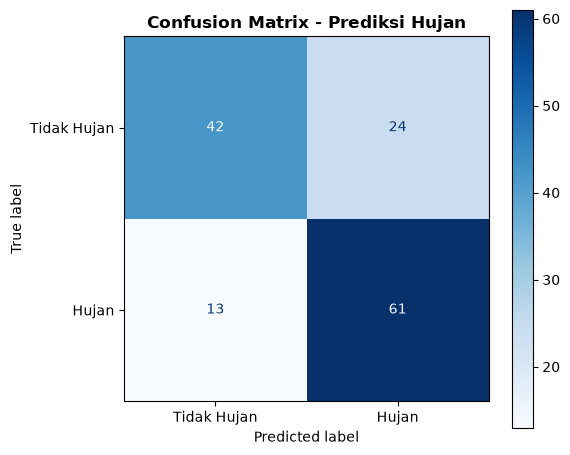


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Tidak Hujan       0.76      0.64      0.69        66
       Hujan       0.72      0.82      0.77        74

    accuracy                           0.74       140
   macro avg       0.74      0.73      0.73       140
weighted avg       0.74      0.74      0.73       140



In [25]:
# === CONFUSION MATRIX ===
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

y_pred = model_final.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    model_final, X_test, y_test,
    display_labels=['Tidak Hujan', 'Hujan'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix - Prediksi Hujan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, 
                            target_names=['Tidak Hujan', 'Hujan']))

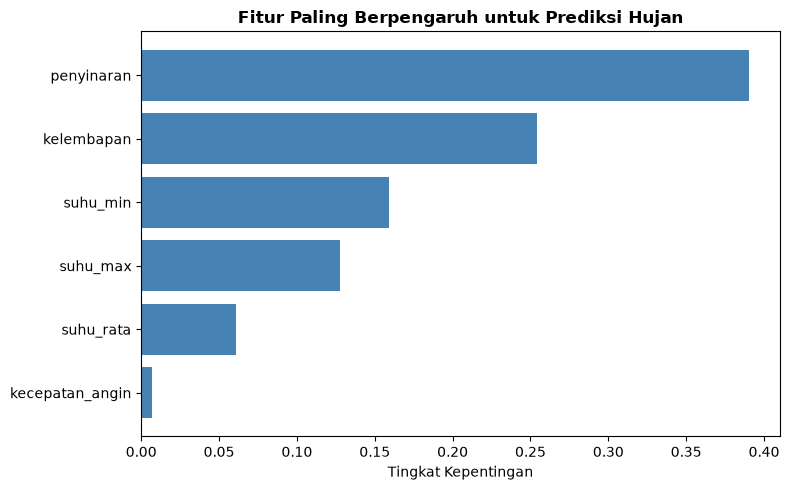

          Fitur  Importance
     penyinaran    0.390579
     kelembapan    0.254474
       suhu_min    0.159410
       suhu_max    0.127492
      suhu_rata    0.061147
kecepatan_angin    0.006897


In [26]:
# === FEATURE IMPORTANCE ===
importance = pd.DataFrame({
    'Fitur': fitur,
    'Importance': model_final.feature_importances_
}).sort_values('Importance', ascending=False)

# Grafik
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance['Fitur'], importance['Importance'], color='steelblue')
ax.set_xlabel('Tingkat Kepentingan')
ax.set_title('Fitur Paling Berpengaruh untuk Prediksi Hujan', 
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

In [27]:
# === SIMPAN MODEL ===
import joblib
import os

# Simpan model
model_path = '../data/processed/model_prediksi_hujan.pkl'
joblib.dump(model_final, model_path)

# Cek file tersimpan
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / 1024
    print(f"✅ Model tersimpan: {model_path}")
    print(f"   Ukuran file: {size:.1f} KB")
else:
    print("❌ Gagal simpan model")

print()
print("Cara load di masa depan:")
print("  import joblib")
print("  model = joblib.load('../data/processed/model_prediksi_hujan.pkl')")

✅ Model tersimpan: ../data/processed/model_prediksi_hujan.pkl
   Ukuran file: 147.5 KB

Cara load di masa depan:
  import joblib
  model = joblib.load('../data/processed/model_prediksi_hujan.pkl')


## 🤖 Model ML — Prediksi Hujan Sulawesi Tenggara

**Tujuan:** Prediksi apakah suatu hari akan hujan atau tidak.

**Algoritma:** Random Forest Classifier

**Konfigurasi Terbaik:**
- `n_estimators=100`
- `max_depth=3`
- `min_samples_split=20`
- `min_samples_leaf=10`

**Hasil:**
| Metrik | Nilai |
|---|---|
| Akurasi Training | 74.42% |
| Akurasi Testing | 73.57% |
| Gap | 0.85% ✅ |

**Feature Importance:**
1. **penyinaran** (39%) — indikator utama awan
2. **kelembapan** (25%)
3. **suhu_min** (16%)
4. suhu_max (13%)
5. suhu_rata (6%)
6. kecepatan_angin (0.7%)

**Insight:**
- Model lebih baik prediksi hari hujan (recall 82%) daripada hari kering (64%)
- `penyinaran` jadi fitur terpenting — sesuai meteorologi, penyinaran singkat = banyak awan = hujan
- `kecepatan_angin` hampir tidak berpengaruh

**Catatan:** Akurasi 73% wajar untuk prediksi cuaca dengan dataset kecil (699 baris).